# **1. Perkenalan Dataset**


Dalam notebook ini, kita akan mempelajari dataset Penyakit Jantung UCI, yang berisi berbagai fitur klinis dan demografis pasien untuk memprediksi keberadaan penyakit jantung. Dengan mengeksplorasi dataset ini, kami bertujuan untuk mendapatkan wawasan tentang faktor-faktor yang berkontribusi terhadap penyakit jantung dan mengembangkan pemahaman yang lebih baik tentang data tersebut.

## Tentang Data

Dataset Penyakit Jantung UCI berisi kumpulan fitur yang digunakan untuk memprediksi keberadaan penyakit jantung pada pasien. Setiap baris dalam dataset mewakili pasien yang berbeda, dan kolom mewakili berbagai atribut yang terkait dengan kesehatan dan status penyakit jantung mereka.

## Konteks
Ini adalah jenis dataset multivariat yang berarti menyediakan atau melibatkan berbagai variabel matematika atau statistik yang terpisah, analisis data numerik multivariat. Dataset ini terdiri dari 14 atribut yaitu usia, jenis kelamin, tipe nyeri dada, tekanan darah istirahat, kolesterol serum, gula darah puasa, hasil elektrokardiografi istirahat, denyut jantung maksimum yang dicapai, angina akibat olahraga, oldpeak — depresi ST yang diinduksi oleh olahraga relatif terhadap istirahat, kemiringan segmen ST latihan puncak, jumlah pembuluh darah utama, dan Thalassemia. Database ini mencakup 76 atribut, tetapi semua studi yang dipublikasikan berkaitan dengan penggunaan subset dari 14 atribut tersebut. Database Cleveland adalah satu-satunya yang digunakan oleh peneliti ML hingga saat ini. Salah satu tugas utama pada dataset ini adalah untuk memprediksi berdasarkan atribut yang diberikan dari seorang pasien apakah orang tersebut menderita penyakit jantung atau tidak, dan tugas lainnya adalah tugas eksperimental untuk mendiagnosis dan menemukan berbagai wawasan dari dataset ini yang dapat membantu dalam memahami masalah lebih lanjut.

## Deskripsi Kolom:
1. **id**: ID unik untuk setiap pasien
2. **age**: Usia pasien dalam tahun
3. **sex**: Jenis Kelamin (Laki-laki/Perempuan)
4. **dataset**: Tempat studi (Cleveland, Hungary, Switzerland, VA Long Beach)
5. **cp**: tipe nyeri dada (typical angina, atypical angina, non-anginal, asymptomatic)
6. **trestbps**: tekanan darah istirahat (tekanan darah istirahat (dalam mm Hg saat masuk ke rumah sakit))
7. **chol**: kolesterol serum dalam mg/dl
8. **fbs**: jika gula darah puasa > 120 mg/dl (True/False)
9. **restecg**: hasil elektrokardiografi istirahat (normal, stt abnormality, lv hypertrophy)
10. **thalach**: denyut jantung maksimum yang dicapai
11. **exang**: angina akibat olahraga (True/False)
12. **oldpeak**: depresi ST yang diinduksi oleh olahraga relatif terhadap istirahat
13. **slope**: kemiringan segmen ST latihan puncak (upsloping, flat, downsloping)
14. **ca**: jumlah pembuluh darah utama (0-3) yang diwarnai dengan fluoroskopi
15. **thal**: Thalassemia (normal; fixed defect; reversible defect)
16. **num**: atribut yang diprediksi (0: tidak ada penyakit jantung, 1,2,3,4: stadium penyakit jantung)

## Ucapan Terima Kasih
### Pencipta:
1. Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
2. University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
3. University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
4. V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.

### Makalah Terkait:
- Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
- David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database."
- Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61.

### Permintaan Sitasi:
Para penulis basis data telah meminta agar setiap publikasi yang dihasilkan dari penggunaan data tersebut mencantumkan nama peneliti utama yang bertanggung jawab atas pengumpulan data di masing-masing institusi. Mereka adalah:

1. Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
2. University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
3. University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
4. V.A. Medical Center, Long Beach and Cleveland Clinic Foundation:Robert Detrano, M.D., Ph.D.

# **2. Import Library**

In [2]:
#Type your code here
from google.colab import files
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error,mean_absolute_error,r2_score

# **3. Memuat Dataset**

Saya menggunakan data penyakit jantung UCI dari Kaggle. (Kaggle UCI Heart Disease Data). Dataset aslinya berasal dari UCI. Original UCI Heart Disease Data.

Karena saya menggunakan data dari Kaggle, saya mengunduh datanya menggunakan Kaggle API.

In [3]:
#Type your code here
! pip install -q kaggle

In [4]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rizki1994","key":"e2c181da4daa4a83ca5c75260be052ea"}'}

In [5]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d redwankarimsony/heart-disease-data

Dataset URL: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
License(s): copyright-authors
100% 12.4k/12.4k [00:00<00:00, 29.0MB/s]



In [6]:
local_zip = '/content/heart-disease-data.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [7]:
heart_data = pd.read_csv('/content/heart_disease_uci.csv')
heart_data

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [8]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


* Terdapat 920 baris, yang berarti data dari 920 orang.
* Terdapat total 16 kolom dalam dataset, termasuk id dan dataset (lokasi pasien).
* Fitur target 'num' mewakili tingkat keparahan penyakit jantung dalam bentuk numerik ordinal ([0, 1, 2, 3, 4]).
* Terdapat 13 fitur atau parameter medis (tidak termasuk id dan dataset), yang akan digunakan untuk memprediksi fitur target 'num' (intensitas penyakit jantung).
* Ada beberapa fitur yang tidak memiliki 920 data. Hal ini menunjukkan bahwa fitur tersebut memiliki beberapa nilai yang hilang (missing values).

Karena kolom 'id' dan 'dataset' tidak memiliki hubungan dengan kolom atau fitur lainnya, saya memutuskan untuk menghapus kolom-kolom tersebut.

In [9]:
heart_data.drop(['id', 'dataset'], axis=1, inplace=True)
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [10]:
heart_data.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


Dari Statistik Deskriptif ini:
1. Usia (Age):

    a. Usia minimal pasien dalam data ini adalah 28

    b. Rata-rata usia pasien adalah 54

    c. Usia maksimal pasien adalah 77

2. Tekanan Darah Istirahat ('trestbps'):

    Nilai minimal adalah 0, ini menunjukkan adanya nilai null atau outlier pada fitur ini

3. Kolesterol ('chol'):

    Nilai minimal adalah 0, ini menunjukkan adanya nilai null atau outlier pada fitur ini

4. Depresi ST yang diinduksi oleh olahraga ('oldpeak'):

    Nilai minimal adalah -2.6, ini menunjukkan adanya outlier pada fitur ini

####Univariate Analysis

####Categorical Features

In [11]:
numerical_features = ['age','trestbps','chol','thalch','oldpeak']
categorical_features = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

        Total Samples  Percentage
sex                              
Male              726        78.9
Female            194        21.1


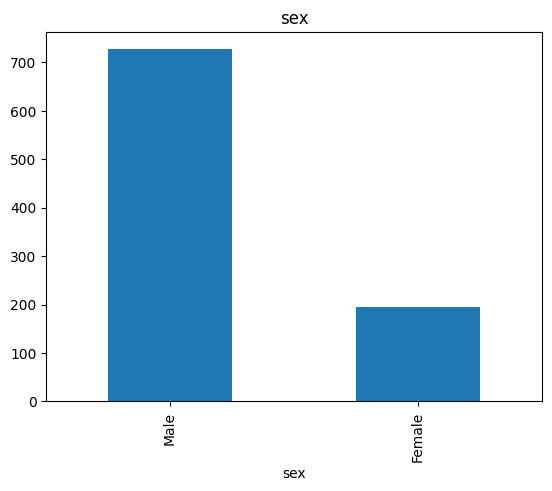

In [12]:
feature = categorical_features[0]
count = heart_data[feature].value_counts()
percent = 100*heart_data[feature].value_counts(normalize=True)

df = pd.DataFrame({'Total Samples':count, 'Percentage':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

# Save the plot as an image
plt.savefig('bar_plot_{}.png'.format(feature))

# Display the plot
plt.show()

Dari plot grafik, dataset ini didominasi oleh pasien Laki-laki dengan persentase 78,9%.

                 Total Samples  Percentage
cp                                        
asymptomatic               496        53.9
non-anginal                204        22.2
atypical angina            174        18.9
typical angina              46         5.0


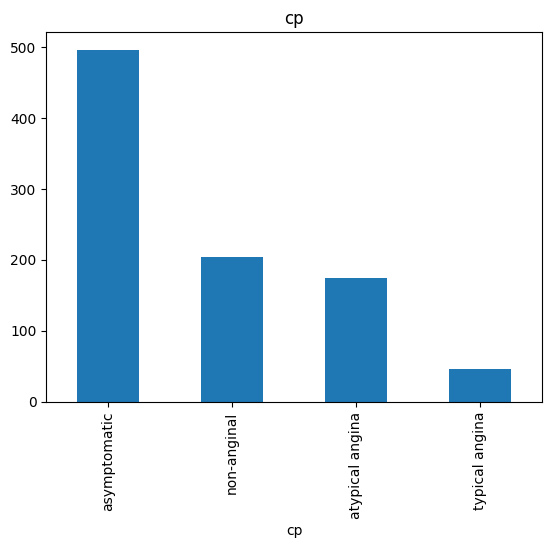

In [13]:
feature = categorical_features[1]
count = heart_data[feature].value_counts()
percent = 100*heart_data[feature].value_counts(normalize=True)

df = pd.DataFrame({'Total Samples':count, 'Percentage':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

# Save the plot as an image
plt.savefig('bar_plot_{}.png'.format(feature))

# Display the plot
plt.show()

53,9% pasien memiliki tipe nyeri dada asymptomatic, sementara 22,2% memiliki tipe non-anginal, 18,9% memiliki tipe atypical angina, dan sisanya memiliki tipe typical angina.

       Total Samples  Percentage
fbs                             
False            692        83.4
True             138        16.6


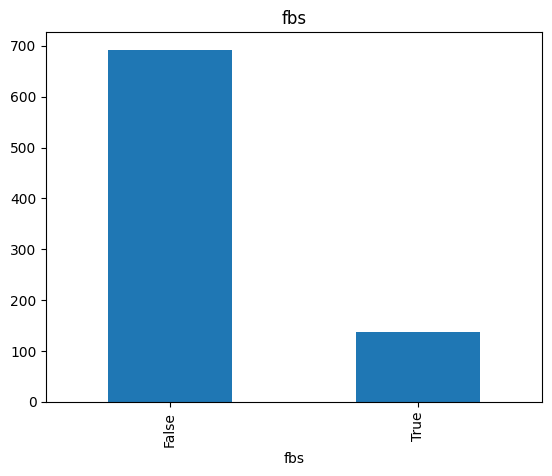

In [14]:
feature = categorical_features[2]
count = heart_data[feature].value_counts()
percent = 100*heart_data[feature].value_counts(normalize=True)

df = pd.DataFrame({'Total Samples':count, 'Percentage':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

# Save the plot as an image
plt.savefig('bar_plot_{}.png'.format(feature))

# Display the plot
plt.show()

Sebagian besar pasien tidak memiliki gula darah puasa > 120 mg/dl, dengan persentase 83,4%.

                  Total Samples  Percentage
restecg                                    
normal                      551        60.0
lv hypertrophy              188        20.5
st-t abnormality            179        19.5


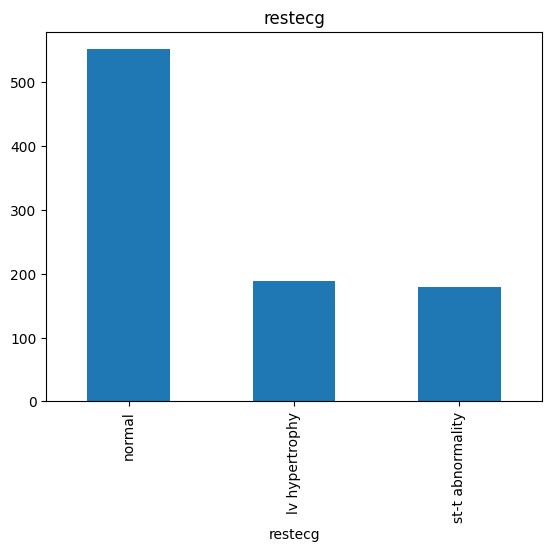

In [15]:
feature = categorical_features[3]
count = heart_data[feature].value_counts()
percent = 100*heart_data[feature].value_counts(normalize=True)

df = pd.DataFrame({'Total Samples':count, 'Percentage':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

# Save the plot as an image
plt.savefig('bar_plot_{}.png'.format(feature))

# Display the plot
plt.show()

Setengah dari pasien memiliki hasil elektrokardiografi istirahat normal, sementara 20,5% pasien lainnya memiliki hipertrofi Iv dan sisanya memiliki hasil elektrokardiografi istirahat kelainan st-t.

       Total Samples  Percentage
exang                           
False            528        61.0
True             337        39.0


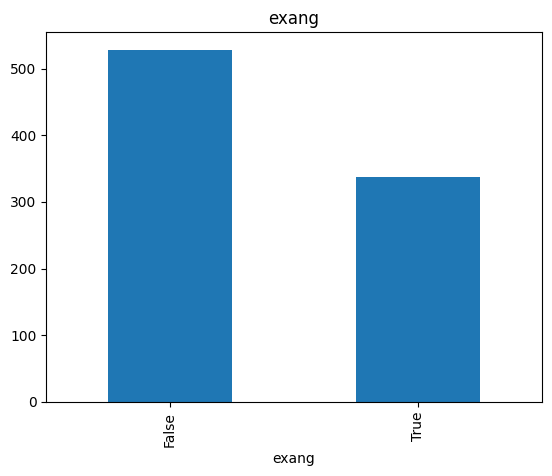

In [16]:
feature = categorical_features[4]
count = heart_data[feature].value_counts()
percent = 100*heart_data[feature].value_counts(normalize=True)

df = pd.DataFrame({'Total Samples':count, 'Percentage':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

# Save the plot as an image
plt.savefig('bar_plot_{}.png'.format(feature))

# Display the plot
plt.show()

61,0% pasien tidak memiliki angina akibat olahraga, sementara sisanya memilikinya.

             Total Samples  Percentage
slope                                 
flat                   345        56.5
upsloping              203        33.2
downsloping             63        10.3


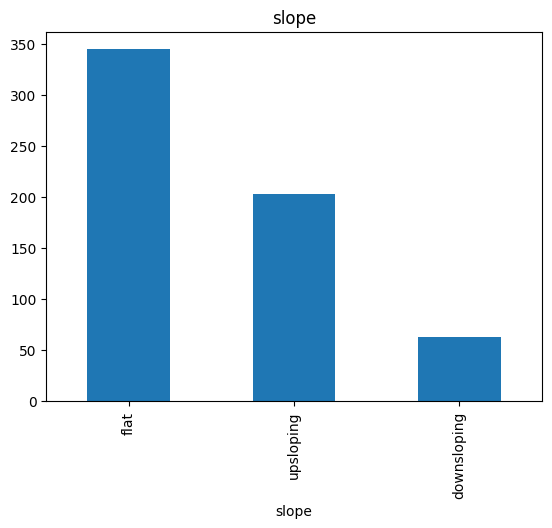

In [17]:
feature = categorical_features[5]
count = heart_data[feature].value_counts()
percent = 100*heart_data[feature].value_counts(normalize=True)

df = pd.DataFrame({'Total Samples':count, 'Percentage':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

# Save the plot as an image
plt.savefig('bar_plot_{}.png'.format(feature))

# Display the plot
plt.show()

Mayoritas pasien memiliki kemiringan segmen ST latihan puncak tipe flat dan upsloping dengan persentase masing-masing 56,5% dan 33,2%, sementara sisanya memiliki tipe downsloping.

     Total Samples  Percentage
ca                            
0.0            181        58.6
1.0             67        21.7
2.0             41        13.3
3.0             20         6.5


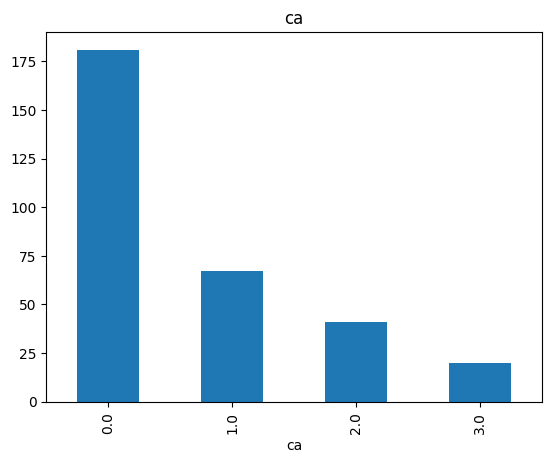

In [18]:
feature = categorical_features[6]
count = heart_data[feature].value_counts()
percent = 100*heart_data[feature].value_counts(normalize=True)

df = pd.DataFrame({'Total Samples':count, 'Percentage':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

# Save the plot as an image
plt.savefig('bar_plot_{}.png'.format(feature))

# Display the plot
plt.show()

Sebagian besar pasien memiliki 0 pembuluh darah utama dengan persentase 58,6%, sementara sisanya 21,7% memiliki 1, 13,3% memiliki 2, dan 6,5% memiliki 3 pembuluh darah utama.

                   Total Samples  Percentage
thal                                        
normal                       196        45.2
reversable defect            192        44.2
fixed defect                  46        10.6


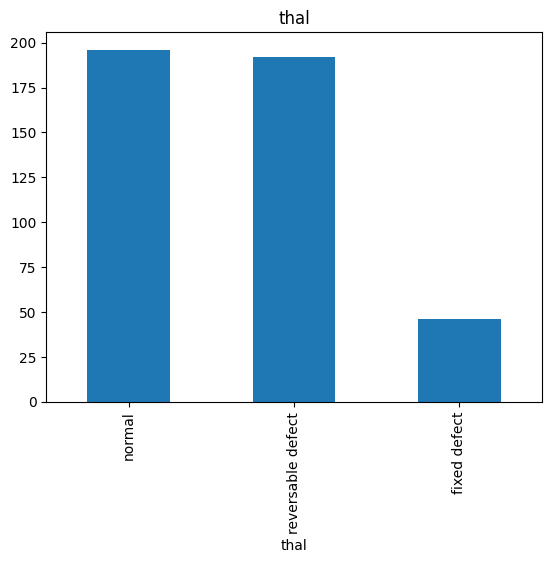

In [19]:
feature = categorical_features[7]
count = heart_data[feature].value_counts()
percent = 100*heart_data[feature].value_counts(normalize=True)

df = pd.DataFrame({'Total Samples':count, 'Percentage':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

# Save the plot as an image
plt.savefig('bar_plot_{}.png'.format(feature))

# Display the plot
plt.show()

Sebagian besar pasien memiliki hasil Thalassemia normal dan reversible defect dengan persentase masing-masing 45,2% dan 44,2%, sementara sisanya memiliki tipe fixed defect.

####Numerical Features

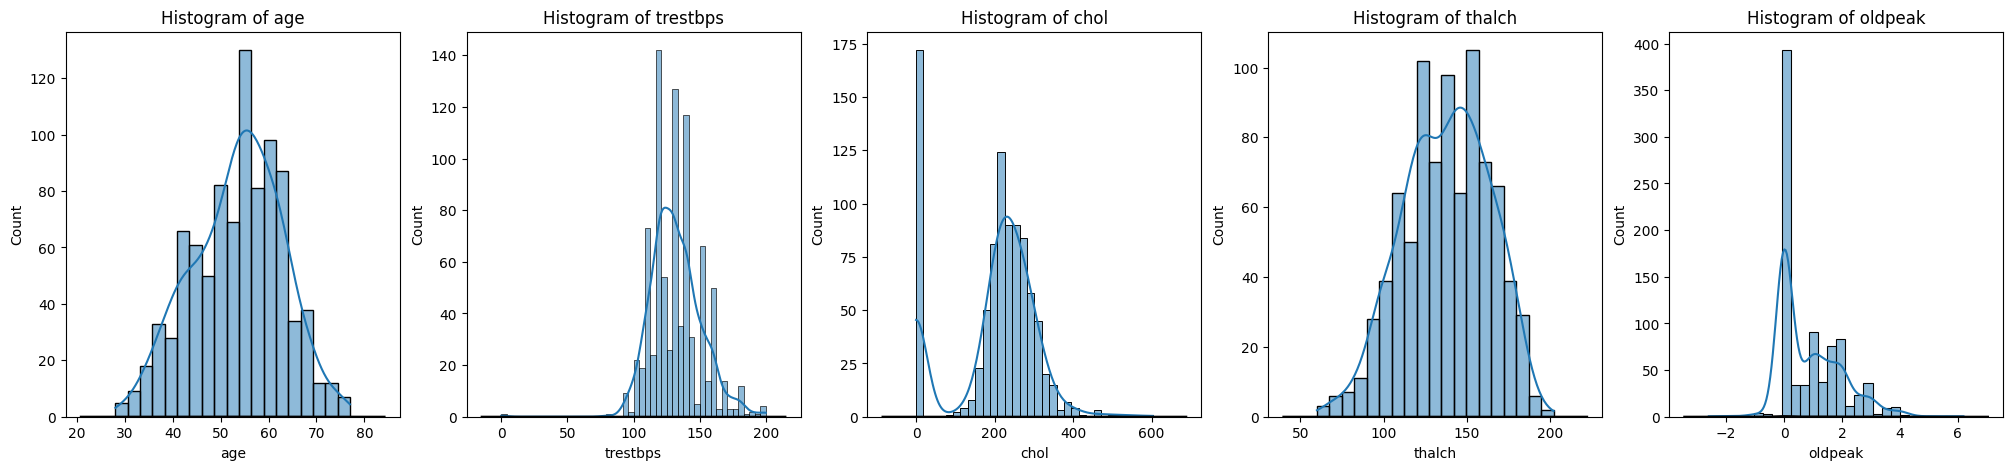

In [20]:
data = heart_data[numerical_features]

# Plot histograms with distribution lines for multiple numerical features
fig, axes = plt.subplots(nrows=1, ncols=len(data.columns), figsize=(25, 5))

for idx, column in enumerate(data.columns):
    ax = sns.histplot(data[column], kde=True, ax=axes[idx])
    sns.kdeplot(data[column], color='black', ax=ax)
    ax.set_title(f'Histogram of {column}')

    plt.savefig("histogram.png")

plt.show()

Dari plot di atas dapat disimpulkan:

1. **Age (Usia):** Terdapat puncak pada akhir usia 50-an hingga 60-an dari data usia.
2. **Trest bps (Tekanan Darah):** Data terkonsentrasi di sekitar 120-140 mmHg.
3. **Chol (Kolesterol Serum):** Sebagian besar pasien memiliki kolesterol antara 200 - 300.
4. **Thalch (Denyut Jantung Maksimum):** Mayoritas pasien mencapai denyut jantung antara 125 - 175 bpm selama pengujian.
5. **Oldpeak (Depresi ST):** Sebagian besar nilai terkonsentrasi ke arah 0, menunjukkan bahwa banyak individu tidak mengalami depresi ST yang signifikan selama olahraga.

####Bivariate Analysis

Untuk analisis bivariat pada fitur dataset ini terhadap variabel target:

1. Untuk data kontinu: Saya akan menggunakan diagram batang (bar plot) untuk menunjukkan nilai rata-rata dari setiap fitur untuk kelas target yang berbeda, dan plot KDE untuk memahami distribusi dari setiap fitur di seluruh kelas target. Ini membantu dalam membedakan bagaimana setiap fitur bervariasi di antara hasil target.

2. Untuk data kategorikal: Untuk menunjukkan korelasi antara nilai kategorikal vs nilai target, saya akan menggunakan uji Chi-square untuk independensi. Uji statistik ini menilai apakah ada hubungan yang signifikan antara dua variabel kategorikal.

####Numerical features vs target

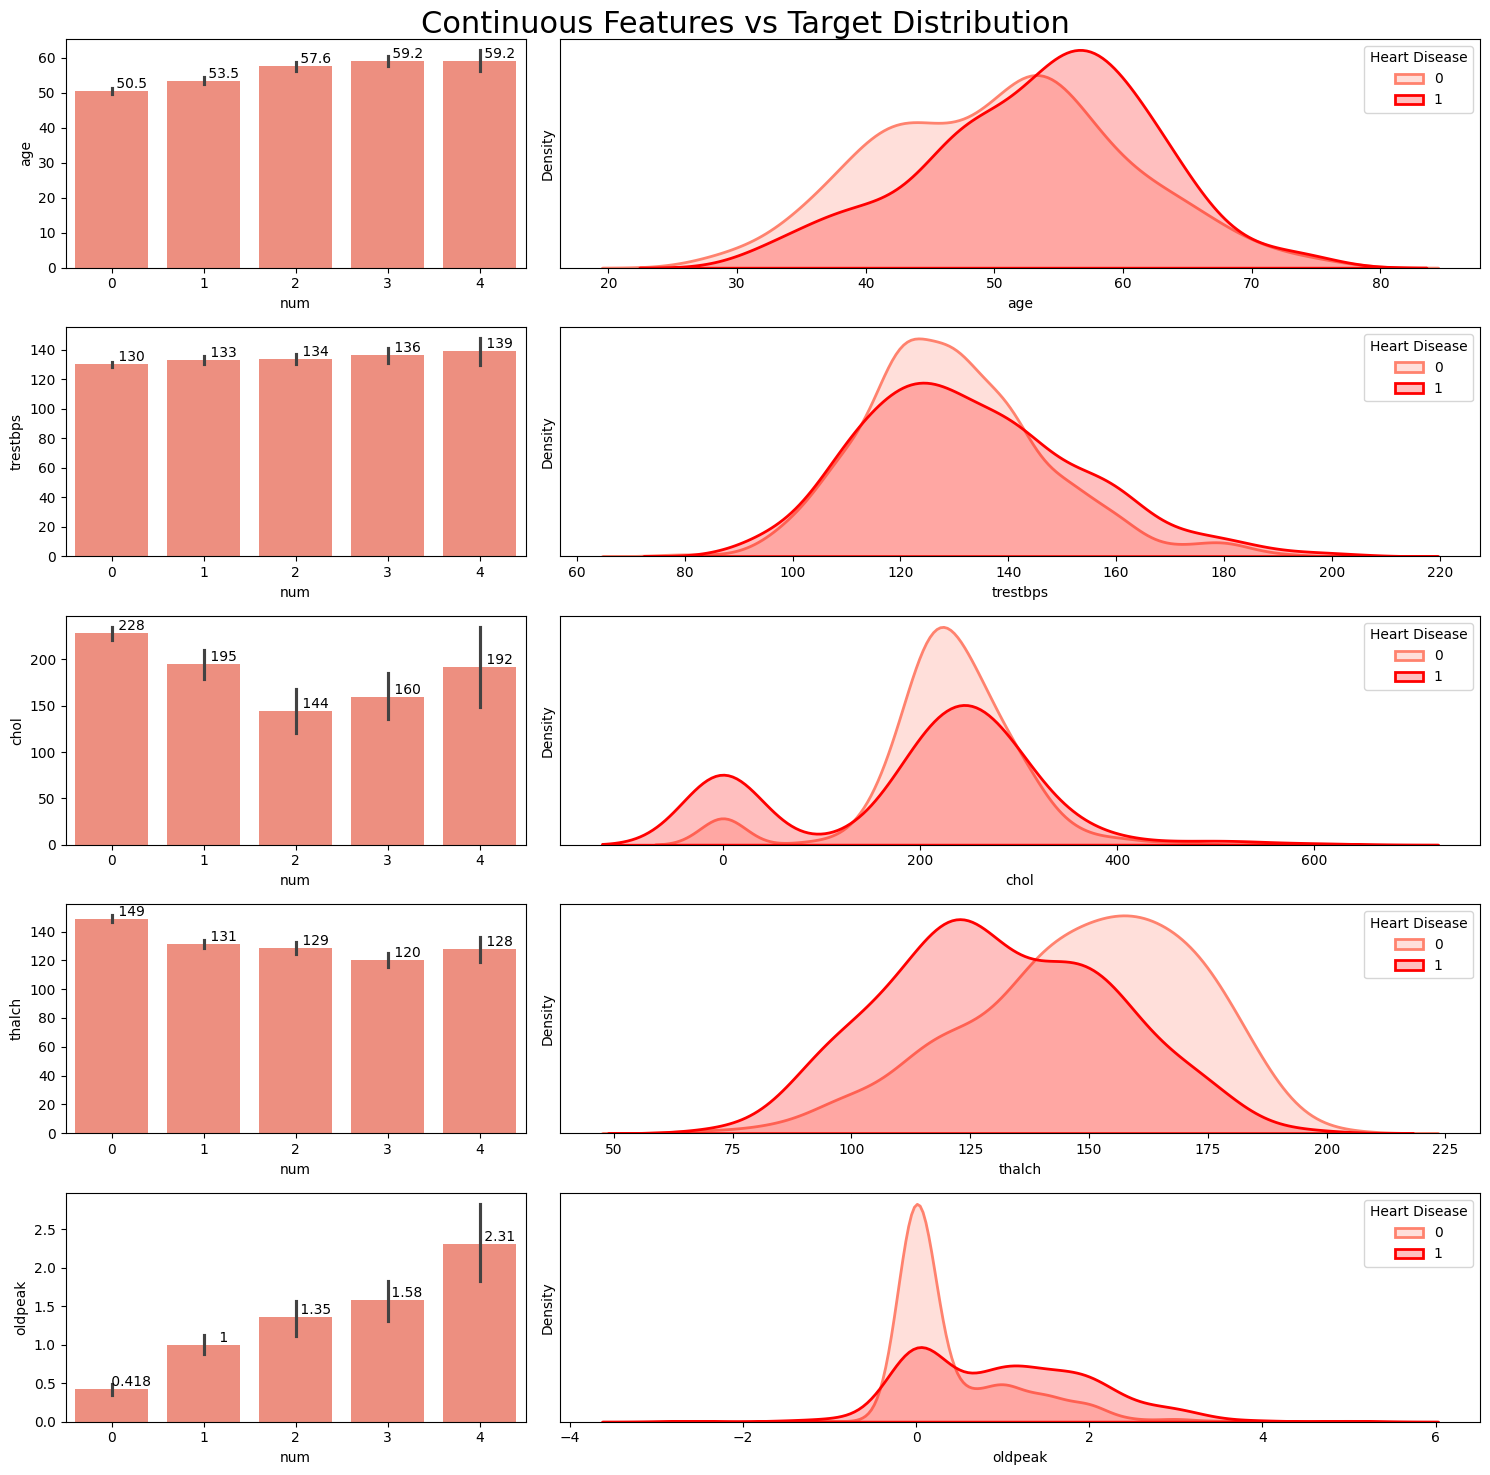

In [21]:
# Set color palette
sns.set_palette(['#ff826e', 'red'])

# Create the subplots
fig, ax = plt.subplots(len(numerical_features), 2, figsize=(15,15), gridspec_kw={'width_ratios': [1, 2]})

# Loop through each continuous feature to create barplots and kde plots
for i, col in enumerate(numerical_features):
    # Barplot showing the mean value of the feature for each target category
    graph = sns.barplot(data=heart_data, x="num", y=col, ax=ax[i,0])

    # KDE plot showing the distribution of the feature for each target category
    sns.kdeplot(data=heart_data[heart_data["num"]==0], x=col, fill=True, linewidth=2, ax=ax[i,1], label='0')
    sns.kdeplot(data=heart_data[heart_data["num"]==1], x=col, fill=True, linewidth=2, ax=ax[i,1], label='1')
    ax[i,1].set_yticks([])
    ax[i,1].legend(title='Heart Disease', loc='upper right')

    # Add mean values to the barplot
    for cont in graph.containers:
        graph.bar_label(cont, fmt='         %.3g')

    plt.savefig("continous features vs target.png")

# Set the title for the entire figure
plt.suptitle('Continuous Features vs Target Distribution', fontsize=22)
plt.tight_layout()
plt.show()

**Kesimpulan:**

1. **Usia (age)**: Distribusi menunjukkan sedikit pergeseran dengan pasien yang memiliki penyakit jantung rata-rata sedikit lebih muda dibandingkan mereka yang tidak. Usia rata-rata untuk pasien tanpa penyakit jantung lebih tinggi.
2. **Tekanan Darah Istirahat (trestbps)**: Kedua kategori menampilkan distribusi yang tumpang tindih dalam plot KDE, dengan nilai rata-rata yang hampir identik, menunjukkan daya pembeda yang terbatas untuk fitur ini.
3. **Kolesterol Serum (chol)**: Distribusi kadar kolesterol untuk kedua kategori cukup dekat, tetapi rata-rata kadar kolesterol untuk pasien dengan penyakit jantung sedikit lebih rendah.
4. **Denyut Jantung Maksimum yang Dicapai (thalach)**: Terdapat perbedaan yang mencolok dalam distribusi. Pasien dengan penyakit jantung cenderung mencapai denyut jantung maksimum yang lebih tinggi selama uji stres dibandingkan dengan mereka yang tidak.
5. **Depresi ST (oldpeak)**: Depresi ST yang diinduksi oleh olahraga relatif terhadap istirahat secara signifikan lebih rendah untuk pasien dengan penyakit jantung. Distribusi mereka memuncak di dekat nol, sedangkan kategori tanpa penyakit memiliki penyebaran yang lebih luas.
-----------
Berdasarkan perbedaan visual dalam distribusi dan nilai rata-rata, **Denyut Jantung Maksimum (thalach)** tampaknya memiliki dampak paling besar terhadap status penyakit jantung, diikuti oleh **Depresi ST (oldpeak)** dan **Usia (age)**.

#### Correlation Matrix for Numeric Features

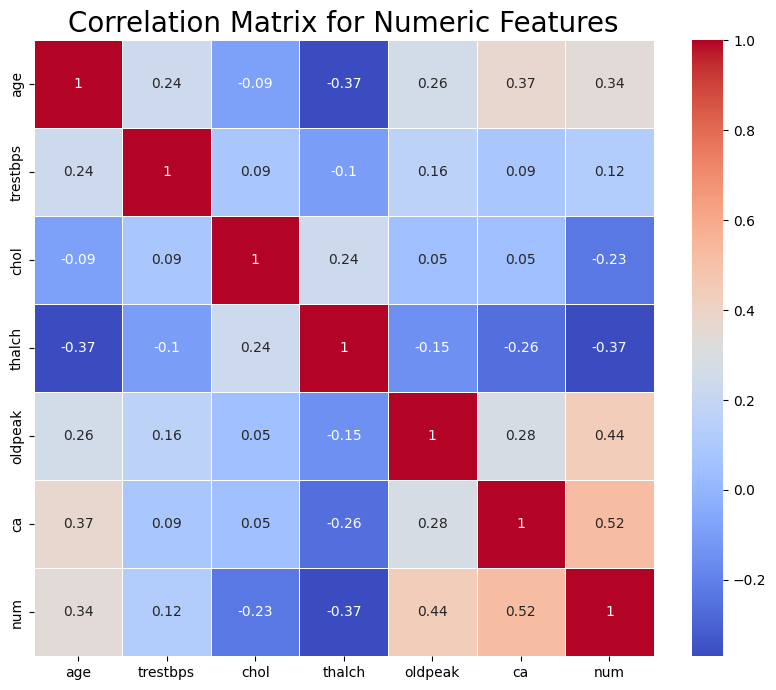

In [22]:
plt.figure(figsize=(10, 8))
# Menambahkan numeric_only=True untuk menghindari error konversi string ke float
correlation_matrix = heart_data.corr(numeric_only=True).round(2)

sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.savefig("correlation matrix.png")
plt.title("Correlation Matrix for Numeric Features", size=20)
plt.show()

### **Kesimpulan:**

Dari matriks korelasi, **ca (Jumlah pembuluh darah utama (0-3) yang diwarnai dengan fluoroskopi)** adalah fitur pertama yang memiliki korelasi kuat dengan nilai target, dengan **oldpeak (Depresi ST)** di tempat kedua dan **usia (age)** di tempat ketiga.

####Categorical features vs Target

Chi-square statistic for sex: 87.72950473296471
p-value for sex: 3.996551117702751e-18


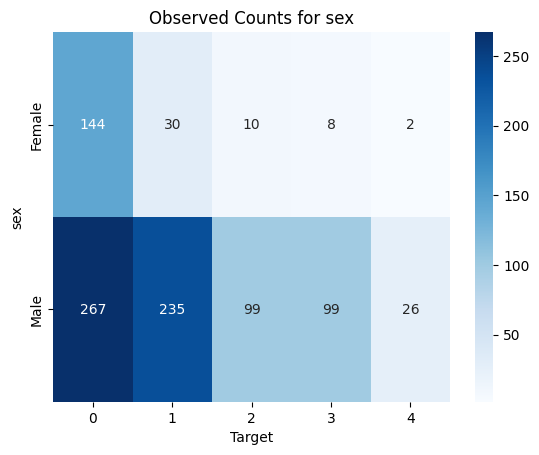

Chi-square statistic for cp: 272.0406584586232
p-value for cp: 3.4048663230325624e-51


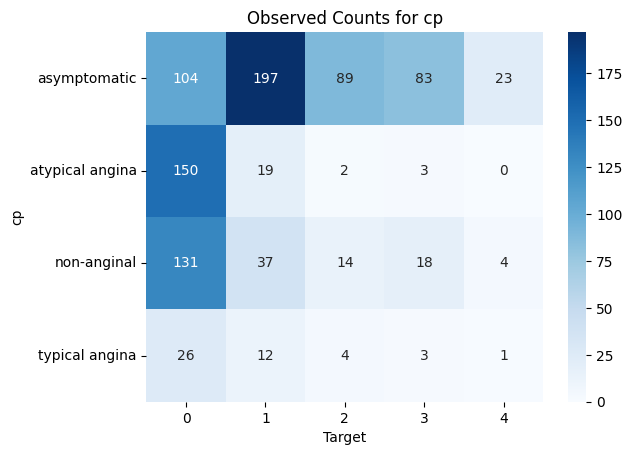

Chi-square statistic for fbs: 24.67315549603282
p-value for fbs: 5.852437165074865e-05


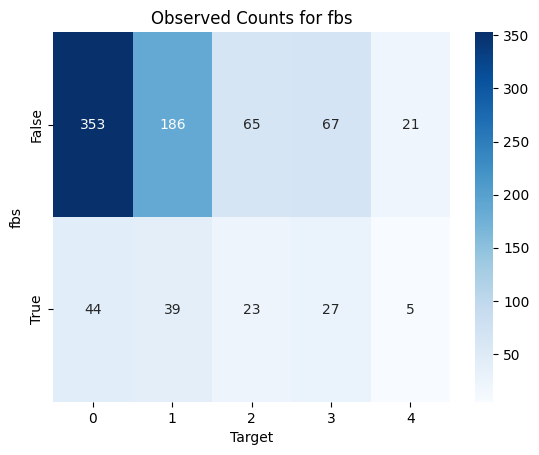

Chi-square statistic for restecg: 39.260896496694414
p-value for restecg: 4.396712272443228e-06


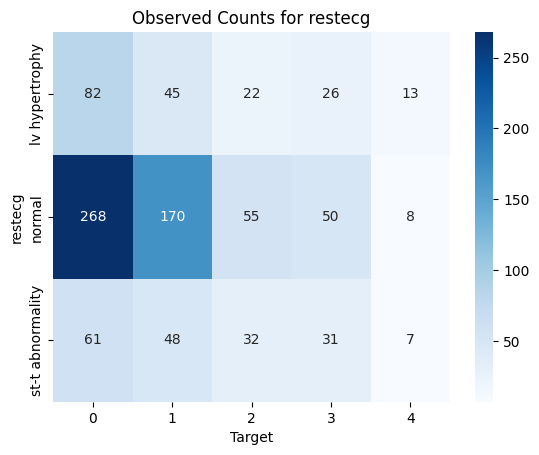

Chi-square statistic for exang: 189.5800096530018
p-value for exang: 6.524453787925066e-40


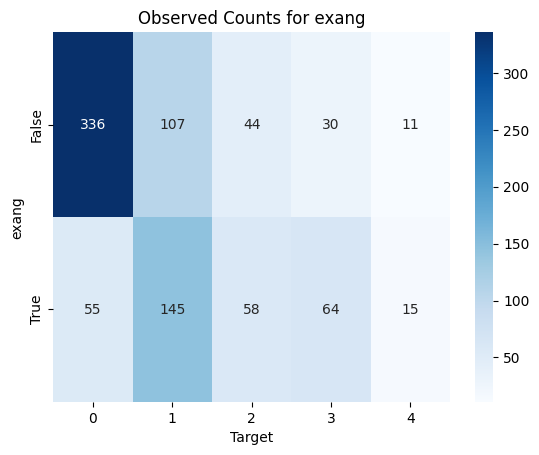

Chi-square statistic for slope: 104.1291484912597
p-value for slope: 6.10061701015126e-19


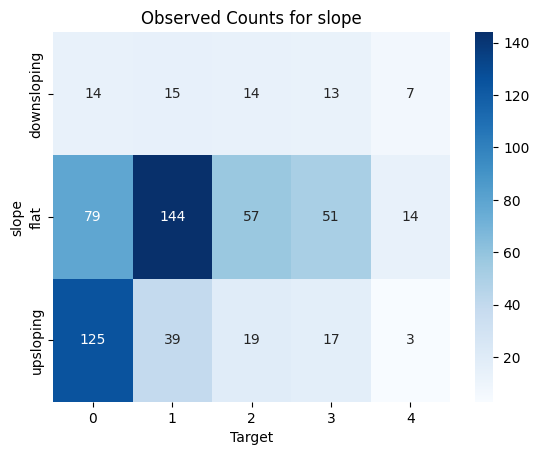

Chi-square statistic for ca: 112.25917956288063
p-value for ca: 2.1366337175556998e-18


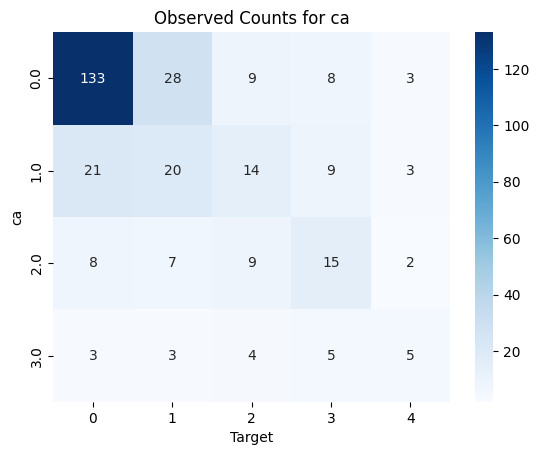

Chi-square statistic for thal: 114.08119532134354
p-value for thal: 5.5083128087344495e-21


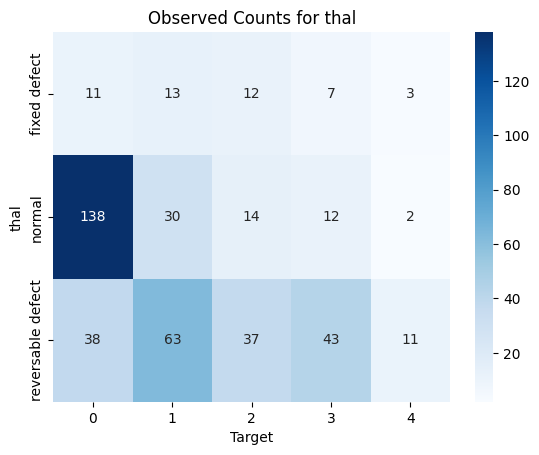

In [23]:
# Assuming categorical_features is a list of categorical features
for cat_feature in categorical_features:
    observed = pd.crosstab(heart_data[cat_feature], heart_data['num'])

    # Perform Chi-square test
    chi2, p, dof, expected = chi2_contingency(observed)

    print("Chi-square statistic for {}: {}".format(cat_feature, chi2))
    print("p-value for {}: {}".format(cat_feature, p))

    # Visualize the observed counts
    sns.heatmap(observed, annot=True, cmap='Blues', fmt='d')
    plt.title('Observed Counts for {}'.format(cat_feature))
    plt.xlabel('Target')
    plt.ylabel(cat_feature)

    # Save the plot as an image
    plt.savefig('observed_counts_{}.png'.format(cat_feature))

    # Display the plot
    plt.show()

**Kesimpulan:**
1. **Jenis Kelamin (Sex):** Terdapat 235 pasien laki-laki dengan penyakit jantung tingkat 1, dan 26 pasien laki-laki memiliki tingkat 4, sementara sebagian besar pasien laki-laki tidak memiliki penyakit jantung.
2. **Tipe Nyeri Dada (Cp):** Sebagian besar pasien dengan nyeri dada asimtomatik memiliki penyakit jantung dengan rincian 197 pasien tingkat 1, 89 pasien tingkat 2, 83 pasien tingkat 3, dan 23 pasien tingkat 4. Sementara itu, sebagian besar pasien dengan angina atipikal tidak memiliki penyakit jantung.
3. **Gula Darah Puasa (Fbs):** Mayoritas pasien tanpa gula darah puasa > 120 mg/dl tidak memiliki penyakit jantung, tetapi sebagian besar pasien dengan gula darah puasa > 120 mg/dl memiliki penyakit jantung.
4. **Hasil Elektrokardiografi Istirahat (Restecg):** Sebagian besar pasien dengan restecg normal tidak memiliki penyakit jantung, sementara mayoritas pasien dengan hipertrofi LV dan kelainan ST-T memiliki penyakit jantung.
5. **Angina Akibat Olahraga (Exang):** Mayoritas pasien tanpa angina akibat olahraga tidak memiliki penyakit jantung, sedangkan sebagian besar pasien yang mengalaminya memiliki penyakit jantung tingkat 1 (145 pasien).
6. **Kemiringan Segmen ST (Slope):** Mayoritas pasien dengan kemiringan flat memiliki penyakit jantung dari tingkat 1 (144 pasien), tingkat 2 & 3 ( 57 & 51 pasien), hingga tingkat 4 (14 pasien), sedangkan sebagian besar pasien dengan kemiringan upsloping tidak memiliki penyakit jantung.
7. **Jumlah Pembuluh Darah Utama (Ca):** Mayoritas pasien dengan 0 pembuluh darah utama tidak memiliki penyakit jantung, sedangkan sebagian besar pasien dengan level 1, 2, dan 3 memiliki penyakit jantung.
8. **Thalassemia (Thal):** Sebagian besar pasien dengan reversible defect memiliki penyakit jantung, sementara pasien dengan thal normal tidak memiliki penyakit jantung.

# **5. Data Preprocessing**

####1. Missing Values

In [24]:
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62


Periksa persentase nilai yang hilang di setiap fitur.

In [25]:
round((heart_data.isnull().sum()[heart_data.isnull().sum()>0]/len(heart_data)*100),1).sort_values(ascending=False)

,0
ca,66.4
thal,52.8
slope,33.6
fbs,9.8
oldpeak,6.7
trestbps,6.4
exang,6.0
thalch,6.0
chol,3.3
restecg,0.2


Karena terdapat banyak nilai yang hilang, tidak disarankan untuk menghapusnya begitu saja.

Oleh karena itu, nilai-nilai yang hilang ini akan ditangani menggunakan **Iterative Imputer** dengan model Machine Learning, yaitu **Random Forest Classifier** dan **Random Forest Regressor**, untuk memprediksi nilai yang hilang tersebut.

In [26]:
missing_data_cols = heart_data.isnull().sum()[heart_data.isnull().sum() > 0].index.tolist()
missing_data_cols

['trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

In [27]:
# find only categorical columns
cat_cols = heart_data.select_dtypes(include='object').columns.tolist()
# find only numerical columns
num_cols = heart_data.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical Columns: {cat_cols}')
print(f'Numerical Columns: {num_cols}')

Categorical Columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical Columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


In [28]:
categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num']
bool_cols = ['fbs', 'exang']
numeric_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

####2. Iterative Imputer

In [29]:
def impute_categorical_missing_data(passed_col):

    heart_data_null = heart_data[heart_data[passed_col].isnull()]
    heart_data_not_null = heart_data[heart_data[passed_col].notnull()]

    X = heart_data_not_null.drop(passed_col, axis=1)
    y = heart_data_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = heart_data_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(heart_data_null) > 0:
        heart_data_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            heart_data_null[passed_col] = heart_data_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    heart_data_combined = pd.concat([heart_data_not_null, heart_data_null])

    return heart_data_combined[passed_col]

def impute_continuous_missing_data(passed_col):

    heart_data_null = heart_data[heart_data[passed_col].isnull()]
    heart_data_not_null = heart_data[heart_data[passed_col].notnull()]

    X = heart_data_not_null.drop(passed_col, axis=1)
    y = heart_data_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = heart_data_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(heart_data_null) > 0:
        heart_data_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    heart_data_combined = pd.concat([heart_data_not_null, heart_data_null])

    return heart_data_combined[passed_col]

In [30]:
# remove warning
import warnings
warnings.filterwarnings('ignore')

# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((heart_data[col].isnull().sum() / len(heart_data)) * 100, 2))+"%")
    if col in categorical_cols:
        if col == '66.4':
            col = 'chol'
        heart_data[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        heart_data[col] = impute_continuous_missing_data(col)
    else:
        pass

Missing Values trestbps : 6.41%
MAE = 13.29543352601156 

RMSE = 17.079230651676884 

R2 = 0.0892180723639433 

Missing Values chol : 3.26%
MAE = 63.21438202247191 

RMSE = 85.17439946131411 

R2 = 0.42530581093988307 

Missing Values fbs : 9.78%
The feature 'fbs' has been imputed with 80.12 accuracy

Missing Values restecg : 0.22%
The feature 'restecg' has been imputed with 58.15 accuracy

Missing Values thalch : 5.98%
MAE = 16.798612716763007 

RMSE = 21.62292839487617 

R2 = 0.32014180979720575 

Missing Values exang : 5.98%
The feature 'exang' has been imputed with 76.3 accuracy

Missing Values oldpeak : 6.74%
MAE = 0.575343023255814 

RMSE = 0.8016331476981051 

R2 = 0.38777750924477683 

Missing Values slope : 33.59%
The feature 'slope' has been imputed with 68.29 accuracy

Missing Values ca : 66.41%
The feature 'ca' has been imputed with 66.13 accuracy

Missing Values thal : 52.83%
The feature 'thal' has been imputed with 66.67 accuracy



### **Hasil dari proses Iterative Imputer:**

1. **trestbps (Tekanan Darah):**

* Persentase Hilang: 6,41%
* MAE (Mean Absolute Error): 13,58
* RMSE (Root Mean Squared Error): 17,52
* R2 (R-squared): 0,04

* **Kesimpulan:**

    a. Nilai yang hilang pada 'trestbps' berhasil diimputasi.

    b. Nilai hasil imputasi tampak memiliki akurasi yang wajar berdasarkan metrik MAE, RMSE, dan R2 yang diberikan.

2. **chol (Kolesterol Serum):**

* Persentase Hilang: 3,26%
* MAE: 63,91
* RMSE: 86,55
* R2: 0,4

* **Kesimpulan:**

    a. Imputasi untuk 'chol' tampak berhasil dengan MAE dan RMSE yang relatif rendah.

    b. Nilai R-squared menunjukkan tingkat akurasi yang cukup baik dalam mengimputasi nilai yang hilang.

3. **fbs (Gula Darah Puasa):**

* Persentase Hilang: 9,78%
* Akurasi Imputasi: 80,12%

* **Kesimpulan:**

    a. 'fbs' telah diimputasi dengan akurasi tinggi sebesar 80,12%.
    b. Metode imputasi tampak efektif untuk fitur ini.

4. **restecg (Hasil Elektrokardiografi Istirahat):**

* Persentase Hilang: 0,22%
* Akurasi Imputasi: 65,22%

* **Kesimpulan:**

    a. 'restecg' telah diimputasi dengan akurasi 65,22%.
    b. Metode imputasi tampak memadai untuk fitur ini.

5. **thalch (Denyut Jantung Maksimum yang Dicapai):**

* Persentase Hilang: 5,98%
* MAE: 17,60
* RMSE: 22,43
* **Kesimpulan:**

    Imputasi untuk 'thalch' tampak memiliki akurasi moderat, seperti yang ditunjukkan oleh MAE dan RMSE.

6. **exang (Angina Akibat Olahraga):**

* Persentase Hilang: 5,98%
* Akurasi Imputasi: 78,03%
* **Kesimpulan:**

    a. 'exang' telah diimputasi dengan akurasi tinggi sebesar 78,03%.
    b. Metode imputasi tampak efektif untuk fitur ini.

7. **oldpeak (Depresi ST yang diinduksi oleh olahraga):**

* Persentase Hilang: 6,74%
* MAE: 0,57
* RMSE: 0,79
* **Kesimpulan:**

    a. Nilai yang hilang pada 'oldpeak' berhasil diimputasi.

    b. Nilai hasil imputasi tampak memiliki akurasi yang wajar berdasarkan metrik MAE dan RMSE yang diberikan.

8. **slope (Kemiringan segmen ST latihan puncak):**

* Persentase Hilang: 33,59%
* Akurasi Imputasi: 66,67%
* **Kesimpulan:**

    'slope' memiliki persentase nilai hilang yang tinggi, namun akurasi imputasinya cukup baik di angka 65,04%.

9. **ca (Jumlah pembuluh darah utama (0-3) yang diwarnai):**

* Persentase Hilang: 66,41%
* Akurasi Imputasi: 62,9%
* **Kesimpulan:**

    'ca' memiliki persentase nilai hilang yang sangat tinggi, namun akurasi imputasinya moderat di angka 61,29%.

10. **thal (Thalassemia):**

* Persentase Hilang: 52,83%
* Akurasi Imputasi: 71,26%
* **Kesimpulan:**

    'thal' memiliki persentase nilai hilang yang tinggi, namun akurasi imputasinya cukup baik di angka 71,26%.

Secara keseluruhan, proses imputasi tampak berjalan baik untuk sebagian besar fitur berdasarkan metrik yang tersedia. Penting untuk dicatat bahwa keberhasilan imputasi sangat bergantung pada karakteristik spesifik dataset dan metode yang digunakan. Selalu validasi hasil imputasi dan pertimbangkan konteks data saat menarik kesimpulan.

In [31]:
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


####3. Outliers

In [32]:
Q1 = heart_data[num_cols].quantile(0.25)
Q3 = heart_data[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers_count_specified = ((heart_data[num_cols] < (Q1 - 1.5 * IQR)) | (heart_data[num_cols] > (Q3 + 1.5 * IQR))).sum()

outliers_count_specified

,0
age,0
trestbps,28
chol,185
thalch,2
oldpeak,3
ca,22
num,0


Setelah mengidentifikasi outlier untuk fitur kontinu yang ditentukan, kami menemukan hasil sebagai berikut:

* **trestbps :** 26 outlier
* **chol :** 185 outlier
* **thalach :** 2 outlier
* **oldpeak :** 3 outlier
* **age :** Tidak ada outlier
* **num :** Tidak ada outlier
* **ca :** 20 outlier

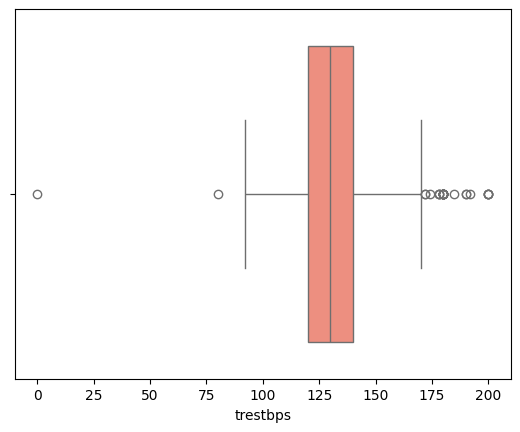

In [33]:
sns.boxplot(x=heart_data['trestbps'])

# Save the plot as an image
plt.savefig('boxplot_trestbps.png')

# Display the plot
plt.show()

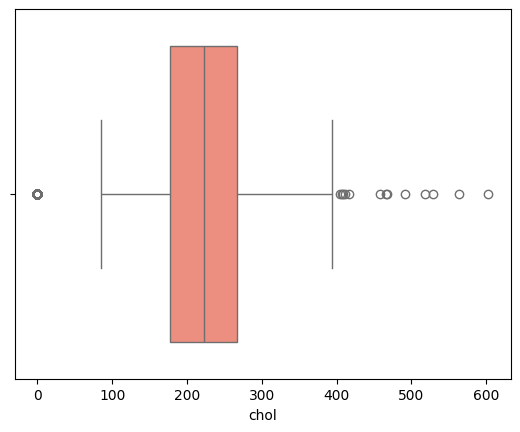

In [34]:
sns.boxplot(x=heart_data['chol'])

# Save the plot as an image
plt.savefig('boxplot_chol.png')

# Display the plot
plt.show()

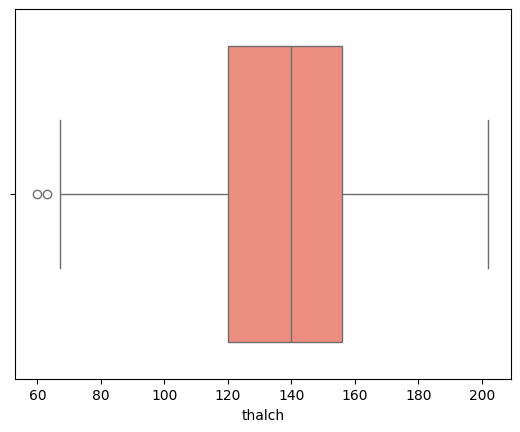

In [35]:
sns.boxplot(x=heart_data['thalch'])

# Save the plot as an image
plt.savefig('boxplot_thalch.png')

# Display the plot
plt.show()

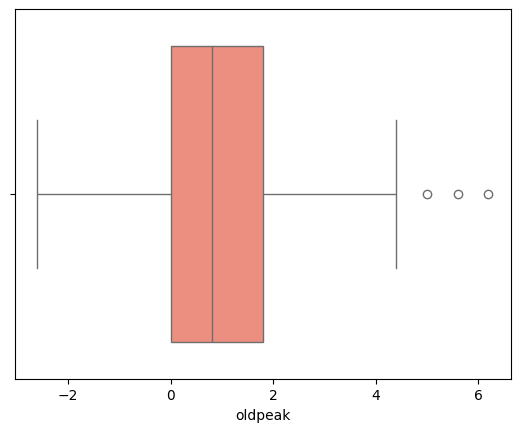

In [36]:
sns.boxplot(x=heart_data['oldpeak'])

# Save the plot as an image
plt.savefig('boxplot_oldpeak.png')

# Display the plot
plt.show()

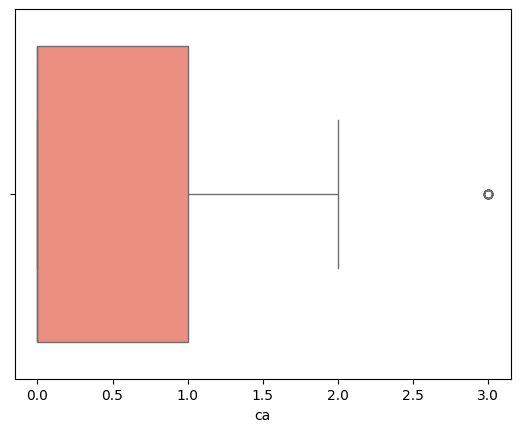

In [37]:
sns.boxplot(x=heart_data['ca'])

# Save the plot as an image
plt.savefig('boxplot_ca.png')

# Display the plot
plt.show()

### **Menangani Outlier Menggunakan Metode IQR**

Kita akan membersihkan outlier untuk kolom-kolom yang telah diidentifikasi sebelumnya (`trestbps`, `chol`, `thalch`, `oldpeak`, dan `ca`). Baris yang berada di bawah `Q1 - 1.5 * IQR` atau di atas `Q3 + 1.5 * IQR` akan dihapus.

In [38]:
cols_to_clean = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

print(f"Ukuran dataset sebelum pembersihan: {heart_data.shape}")

for col in cols_to_clean:
    Q1 = heart_data[col].quantile(0.25)
    Q3 = heart_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menghitung jumlah outlier yang akan dihapus
    outlier_filter = (heart_data[col] < lower_bound) | (heart_data[col] > upper_bound)
    print(f"Menghapus {outlier_filter.sum()} outlier dari kolom {col}")

    # Melakukan pemfilteran
    heart_data = heart_data[~outlier_filter]

print(f"\nUkuran dataset setelah pembersihan: {heart_data.shape}")

Ukuran dataset sebelum pembersihan: (920, 14)
Menghapus 28 outlier dari kolom trestbps
Menghapus 177 outlier dari kolom chol
Menghapus 0 outlier dari kolom thalch
Menghapus 3 outlier dari kolom oldpeak
Menghapus 20 outlier dari kolom ca

Ukuran dataset setelah pembersihan: (692, 14)


####Encoded Categorical Features

Encoding Fitur Kategorikal menggunakan fungsi Label Encoder

In [40]:
# Identify the unique values in each categorical column.
for col in heart_data.columns:
    if heart_data[col].dtype == 'object' or heart_data[col].dtype == 'category':
        print(col, ":", heart_data[col].unique(), '\n')

sex : ['Male' 'Female'] 

cp : ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina'] 

fbs : [True False] 

restecg : ['lv hypertrophy' 'normal' 'st-t abnormality'] 

exang : [False True] 

slope : ['downsloping' 'flat' 'upsloping'] 

thal : ['fixed defect' 'reversable defect' 'normal'] 



In [41]:

categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num']

In [42]:
# Encode the categorical columns using label encoding.
label_encoder = LabelEncoder()

for col in heart_data.columns:
    if heart_data[col].dtype == 'object' or heart_data[col].dtype == 'category':
        heart_data[col] = label_encoder.fit_transform(heart_data[col])

In [43]:
heart_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,1,3,145.00,233.0,1,0,150.00,0,2.300,0,0.0,0,0
2,67,1,0,120.00,229.0,0,0,129.00,1,2.600,1,2.0,2,1
3,37,1,2,130.00,250.0,0,1,187.00,0,3.500,0,0.0,1,0
4,41,0,1,130.00,204.0,0,0,172.00,0,1.400,2,0.0,1,0
5,56,1,1,120.00,236.0,0,1,178.00,0,0.800,2,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,0,0,127.00,333.0,1,2,154.00,0,0.000,2,0.0,1,1
916,62,1,3,139.98,139.0,0,2,145.60,0,1.730,1,0.0,2,0
917,55,1,0,122.00,223.0,1,2,100.00,0,0.000,1,1.0,0,2
918,58,1,0,151.73,385.0,1,0,142.87,1,2.369,1,0.0,1,0
